In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

pd.set_option('display.float_format',"{:.2f}".format)

# OS에 따라 다른 폰트 지정
if platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'
article_df = pd.read_csv("articles_hm.csv")
customer_df = pd.read_csv("customer_hm.csv")
transaction_df = pd.read_csv("transactions_hm.csv")
whole_df = pd.merge(
    pd.merge(
        transaction_df,
        customer_df,
        on = 'customer_id'
    ),
    article_df,
    on ='article_id'
)
df = whole_df.copy() ## 잘 확인하기!!!!
df['price'] = df['price']*1000

In [2]:
df.shape

(812931, 34)

In [3]:
numeric_df = df.select_dtypes(include='number')

In [4]:

numeric_df.head().T

,0,1,2,3,4
article_id,698328010.00,760597002.00,488561032.00,682771001.00,742400033.00
price,16.93,33.88,16.93,33.88,3.22
sales_channel_id,2.00,2.00,2.00,2.00,1.00
FN,1.00,0.00,1.00,0.00,0.00
Active,1.00,0.00,1.00,0.00,0.00
age,51.00,28.00,37.00,19.00,35.00
product_code,698328.00,760597.00,488561.00,682771.00,742400.00
product_type_no,252.00,254.00,274.00,66.00,302.00
graphical_appearance_no,1010014.00,1010017.00,1010024.00,1010016.00,1010001.00
colour_group_code,73.00,10.00,73.00,9.00,10.00


In [5]:
# 연속형 변수
continuous_cols = ['price']
# 이산형 변수 
discrete_cols = ['age']
# 범주형 변수 
# categorical_cols = 

기술 통계

In [6]:
df[continuous_cols].describe()

,price
count,812931.00
mean,27.77
std,19.32
min,0.24
25%,15.24
50%,25.41
75%,33.88
max,506.78


array([[<Axes: title={'center': 'price'}>]], dtype=object)

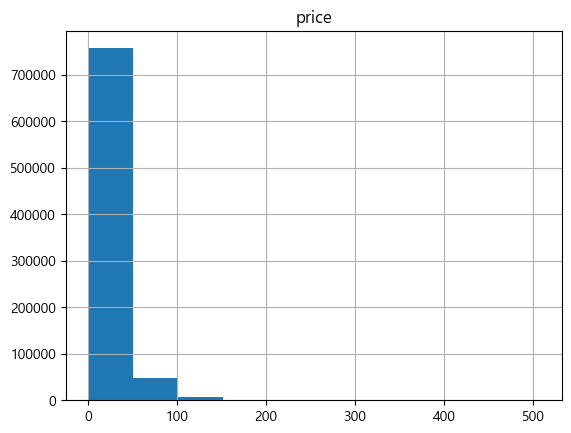

In [7]:
df[continuous_cols].hist()

IQR 방식의 이상치 처리

In [8]:
q_1 = np.percentile(df[continuous_cols], q=25)
q_3 = np.percentile(df[continuous_cols], q=75)
iqr = q_3 - q_1

lower_whisker = q_1 - 1.5*iqr
upper_whisker = q_3 + 1.5*iqr


In [9]:
df_processed = df.loc[df['price'].between(lower_whisker, upper_whisker)]

상관계수

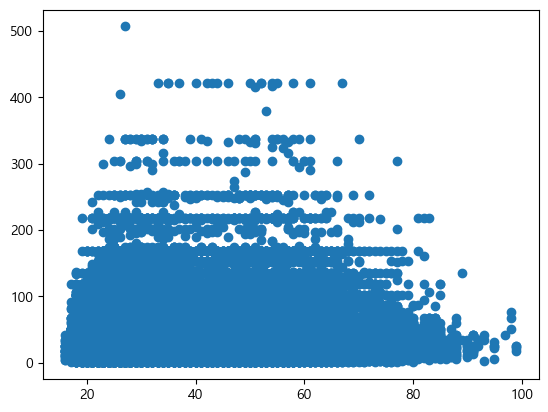

In [10]:
plt.scatter(df['age'], df['price'])

In [11]:
df[['age','price']].corr(method='pearson')

,age,price
age,1.00,0.05
price,0.05,1.00


In [12]:
df[['age','price']].corr(method='spearman')

,age,price
age,1.00,0.05
price,0.05,1.00


In [13]:
df[['age','price']].corr(method= 'kendall')

,age,price
age,1.00,0.03
price,0.03,1.00


## 가설 검정

1. 패션 구독여부에 따라서 평균금액의 차이가 있는가? -> 독립표본 t-검정
2. 동일 카테고리 내에서 색깔에 따라 평균금액의 차이가 있는가? -> 일원 ANOVA
3. 카테고리와 색상 간의 연관성이 있는가? -> 카이제곱 독립성 검정


## 1. 패션 구독여부에 따라서 평균금액의 차이가 있는가? -> 독립표본 t-검정

In [14]:
customer_price_mean = df_processed.groupby(['customer_id',"FN"])['price'].mean()
customer_price_df = customer_price_mean.reset_index()

In [15]:
customer_price_df

,customer_id,FN,price
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,0,52.53
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,0,33.32
2,0000757967448a6cb83efb3ea7a3fb9d418ac7adf2379d...,0,25.41
3,00007d2de826758b65a93dd24ce629ed66842531df6699...,1,20.75
4,00009d946eec3ea54add5ba56d5210ea898def4b46c685...,1,28.27
...,...,...,...
345174,c88f00357e7b1518128c80043e5d2b223308a3ce3fc389...,1,59.31
345175,c88f0d813c429ceb32683c9cb5fcb24331ff198e6e17f2...,1,16.93
345176,c88f5971612e659a4e90d6f08d9c29bdf1e4268fcf52d5...,1,20.49
345177,c88f99a55b10f6dd50dd87c3ca05af4a8a6c98f3e6fbc5...,0,21.45


In [16]:
fn_0 = customer_price_df.loc[customer_price_df['FN']==0,'price'] 
fn_1 = customer_price_df.loc[customer_price_df['FN']==1,'price'] 

In [17]:
sample_size = min(len(fn_0), len(fn_1))

In [18]:
fn_0_sample = fn_0.sample(sample_size, random_state=42)
fn_1_sample = fn_1.copy()

1. 가설 설정
- 귀무가설 : 패션 구독여부에 따른 가격차이가 없다. fn_0 = fn_1
- 대립가설 : 패션 구독여부에 따른 가격차이가 있다. fn_0 != fn_1

2. 검정방법 선택
- 정규성, 등분산성

c:\basic_class_통계_수업\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


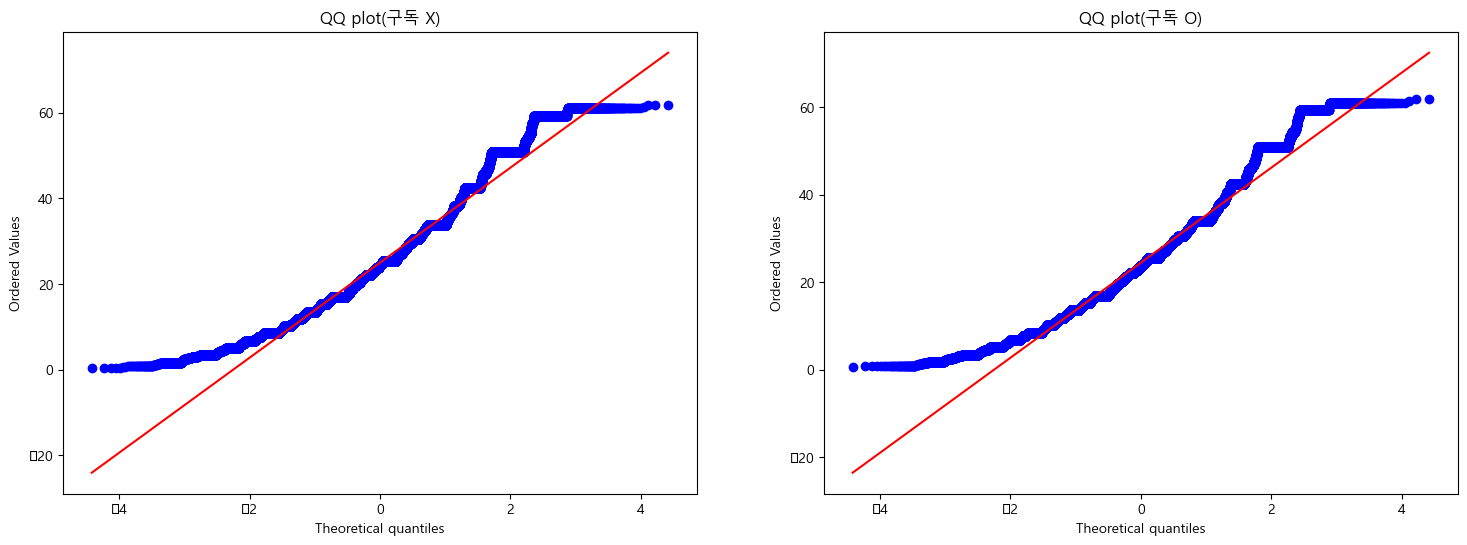

In [19]:
## q-q plot

fig, ax = plt.subplots(1,2, figsize=(18,6))
stats.probplot(fn_0_sample, plot=ax[0])
ax[0].set_title("QQ plot(구독 X)")
stats.probplot(fn_1_sample, plot=ax[1])
ax[1].set_title("QQ plot(구독 O)")

plt.show()

In [20]:
# 정규성 검정
def ks_test(group):
    
    sample_mean = np.mean(group)
    s = np.std(group, ddof=1)

    stat, p = stats.kstest(group,'norm', args=(sample_mean, s))
    return p

ks_test(fn_0_sample), ks_test(fn_1_sample)

(np.float64(0.0), np.float64(0.0))

In [21]:
m_stat, p = stats.mannwhitneyu(fn_0_sample, fn_1_sample, alternative="two-sided")
m_stat, p

(np.float64(10216098229.5), np.float64(1.0446552181578138e-32))

유의 수준 : 0.01
-> 귀무가설 기각 ( p-value가 유의수준보다 작으므로)
-> 패션 구독여부에 따라서 평균구매금액 차이가 있다

## 2. 동일 카테고리 내에서 색깔에 따라 평균금액의 차이가 있는가? -> 일원 ANOVA

1. 가설설정
- 귀무가설 : 같은 카테고리 내에서 색상에 따른 평균 구매금액 차이가 없다. 
- 대립가설 : 같은 카테고리 내에서 평균 구매 금액이 다른 색상이 적어도 하나는 있다. 

카테고리 : Jersey

In [22]:
dress_df = df_processed.loc[df['product_type_name']=='Dress',['customer_id','perceived_colour_master_name','price']]

In [23]:
dress_color_price_df = dress_df.groupby(['customer_id','perceived_colour_master_name'])['price'].mean().reset_index()

In [24]:
dress_color_price_df['perceived_colour_master_name'].value_counts()

perceived_colour_master_name
Black           25243
Blue             7747
White            7738
Beige            5261
Red              5234
Green            3157
Khaki green      3091
Yellow           2707
Pink             2584
Grey             2387
Brown            1969
Orange            959
Turquoise         785
Unknown           773
Mole              189
Lilac Purple      110
undefined          45
Metal              31
Name: count, dtype: int64

In [25]:
dress_black = dress_color_price_df.loc[dress_color_price_df['perceived_colour_master_name']=='Black','price']
dress_blue = dress_color_price_df.loc[dress_color_price_df['perceived_colour_master_name']=='Blue','price']
dress_white = dress_color_price_df.loc[dress_color_price_df['perceived_colour_master_name']=='White','price']
dress_beige = dress_color_price_df.loc[dress_color_price_df['perceived_colour_master_name']=='Beige','price']
dress_red = dress_color_price_df.loc[dress_color_price_df['perceived_colour_master_name']=='Red','price']
dress_green = dress_color_price_df.loc[dress_color_price_df['perceived_colour_master_name']=='Green','price']


In [26]:
dress_black_sample = dress_black.sample(3157, random_state=42).values
dress_blue_sample = dress_blue.sample(3157, random_state=42).values
dress_white_sample = dress_white.sample(3157, random_state=42).values
dress_beige_sample = dress_beige.sample(3157, random_state=42).values
dress_red_sample = dress_red.sample(3157, random_state=42).values
dress_green_sample = dress_green.copy().values

정규성

c:\basic_class_통계_수업\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


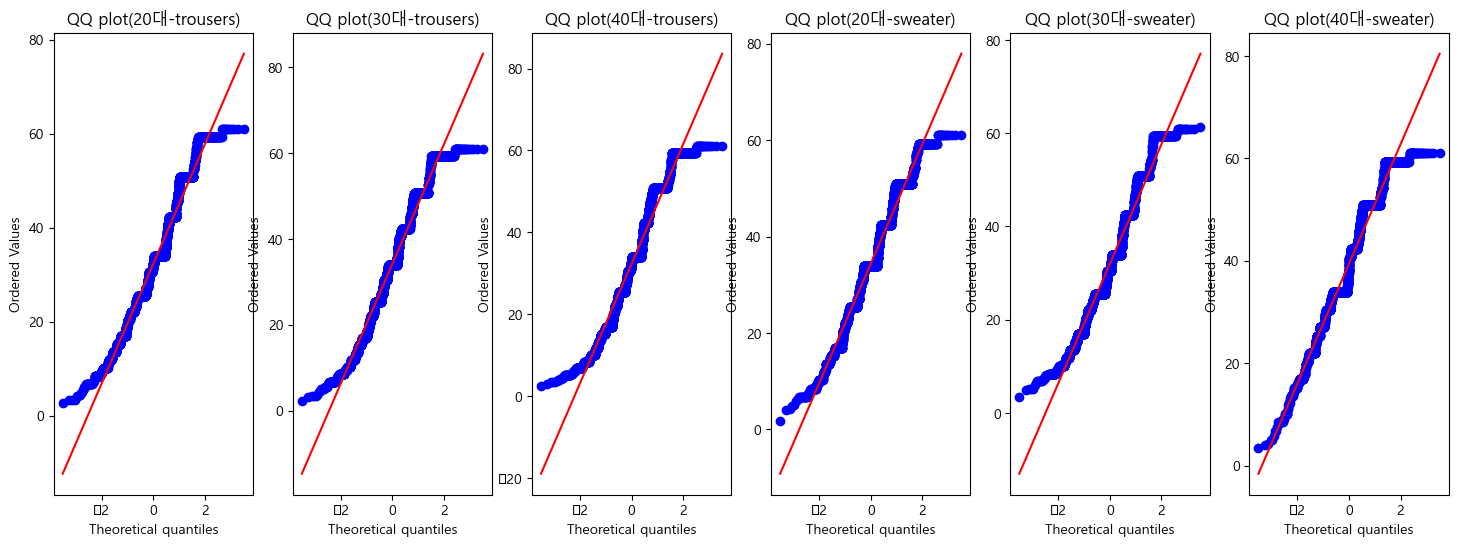

In [27]:
## q-q plot

fig, ax = plt.subplots(1,6, figsize=(18,6))
stats.probplot(dress_black_sample, plot=ax[0])
ax[0].set_title("QQ plot(20대-trousers)")
stats.probplot(dress_blue_sample, plot=ax[1])
ax[1].set_title("QQ plot(30대-trousers)")
stats.probplot(dress_white_sample, plot=ax[2])
ax[2].set_title("QQ plot(40대-trousers)")
stats.probplot(dress_beige_sample, plot=ax[3])
ax[3].set_title("QQ plot(20대-sweater)")
stats.probplot(dress_red_sample, plot=ax[4])
ax[4].set_title("QQ plot(30대-sweater)")
stats.probplot(dress_green_sample, plot=ax[5])
ax[5].set_title("QQ plot(40대-sweater)")

plt.show()

In [ ]:
sample_lst = [dress_black_sample, dress_blue_sample, dress_white_sample, dress_beige_sample, dress_red_sample, dress_green_sample]

for sample in sample_lst:D
    print(ks_test(sample))

3.668683949461851e-43
1.1686133675058231e-17
2.987928221050635e-30
8.061791363831928e-34
1.8482571379773018e-35
8.683595334154429e-65


In [29]:
stat, p = stats.kruskal(*sample_lst)
stat, p

(np.float64(715.8751115221748), np.float64(1.8137945050002546e-152))

p-value가 0.01(유의수준)보다 작으므로 귀무가설 기각

In [ ]:
import numpy as np
import pandas as pd

data = pd.DataFrame({
    'price': np.concatenate(sample_lst), 
    'group': ['black']*3157 + ['blue']*3157 + ['white']*3157 + ['beige']*3157 + ['red']*3157 + ['green']*3157
})

data.head()

,price,group
0,59.31,black
1,15.24,black
2,33.88,black
3,33.88,black
4,59.31,black


In [33]:
import scikit_posthocs as sp

posthoc = sp.posthoc_dunn(data, val_col='price', group_col='group', p_adjust="holm")

In [34]:
posthoc

,beige,black,blue,green,red,white
beige,1.00,0.00,0.95,0.00,0.00,0.00
black,0.00,1.00,0.00,0.00,0.83,0.95
blue,0.95,0.00,1.00,0.00,0.00,0.00
green,0.00,0.00,0.00,1.00,0.00,0.00
red,0.00,0.83,0.00,0.00,1.00,0.45
white,0.00,0.95,0.00,0.00,0.45,1.00


In [35]:
# 사후검정 : Games-Howell
import pingouin as pg

result = pg.pairwise_gameshowell(data=data, dv='price', between='group')
result

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,beige,black,34.36,32.31,2.05,0.32,6.42,6307.59,0.00,0.16
1,beige,blue,34.36,34.24,0.12,0.34,0.35,6226.32,1.00,0.01
2,beige,green,34.36,39.43,-5.07,0.31,-16.49,6293.81,0.00,-0.42
3,beige,red,34.36,32.00,2.36,0.32,7.34,6303.93,0.00,0.18
4,beige,white,34.36,32.34,2.02,0.35,5.84,6138.61,0.00,0.15
5,black,blue,32.31,34.24,-1.94,0.34,-5.69,6260.00,0.00,-0.14
6,black,green,32.31,39.43,-7.12,0.31,-22.85,6271.77,0.00,-0.58
7,black,red,32.31,32.00,0.30,0.33,0.93,6311.45,0.94,0.02
8,black,white,32.31,32.34,-0.03,0.35,-0.09,6186.81,1.00,-0.00
9,blue,green,34.24,39.43,-5.19,0.33,-15.81,6134.72,0.00,-0.40


3. 카테고리와 색상 간의 연관성이 있는가? -> 카이제곱 독립성 검정

In [36]:
ct = pd.crosstab(df_processed['perceived_colour_master_name'],df_processed['index_group_name'])
ct_2 = ct.loc[~ct.index.isin(['Metal','Yellowish Green','undefined'])]

In [37]:
ct_2

index_group_name,Baby/Children,Divided,Ladieswear,Menswear,Sport
perceived_colour_master_name,,,,,
Beige,610,7980,38335,1301,144
Black,4145,66766,165659,11082,16990
Blue,8240,29876,55313,10262,1821
Brown,221,1232,15589,779,48
Green,715,3479,15143,1252,528
Grey,3648,9570,24731,4660,2105
Khaki green,876,4786,13768,1656,31
Lilac Purple,77,303,1788,325,301
Mole,141,1435,5178,257,241


In [38]:
from scipy.stats import chi2_contingency

result = chi2_contingency(ct_2)
result

Chi2ContingencyResult(statistic=np.float64(57005.48301187473), pvalue=np.float64(0.0), dof=60, expected_freq=array([[1.81831885e+03, 1.11926503e+04, 3.08882805e+04, 2.62650973e+03,
        1.84424064e+03],
       [9.94838819e+03, 6.12372412e+04, 1.68995996e+05, 1.43701631e+04,
        1.00902115e+04],
       [3.96639360e+03, 2.44151110e+04, 6.73782148e+04, 5.72934246e+03,
        4.02293815e+03],
       [6.71729161e+02, 4.13482464e+03, 1.14108473e+04, 9.70293620e+02,
        6.81305272e+02],
       [7.93827561e+02, 4.88640058e+03, 1.34849663e+04, 1.14666128e+03,
        8.05144296e+02],
       [1.68088296e+03, 1.03466646e+04, 2.85536195e+04, 2.42798752e+03,
        1.70484548e+03],
       [7.93827561e+02, 4.88640058e+03, 1.34849663e+04, 1.14666128e+03,
        8.05144296e+02],
       [1.05031690e+02, 6.46521913e+02, 1.78420210e+03, 1.51715282e+02,
        1.06529013e+02],
       [2.72616256e+02, 1.67808766e+03, 4.63100703e+03, 3.93786409e+02,
        2.76502649e+02],
       [6.31769001

In [39]:
# 기대도수가 5보다 큰지 확인하기! 
pd.DataFrame(result.expected_freq)

,0,1,2,3,4
0,1818.32,11192.65,30888.28,2626.51,1844.24
1,9948.39,61237.24,168996.00,14370.16,10090.21
2,3966.39,24415.11,67378.21,5729.34,4022.94
3,671.73,4134.82,11410.85,970.29,681.31
4,793.83,4886.40,13484.97,1146.66,805.14
5,1680.88,10346.66,28553.62,2427.99,1704.85
6,793.83,4886.40,13484.97,1146.66,805.14
7,105.03,646.52,1784.20,151.72,106.53
8,272.62,1678.09,4631.01,393.79,276.50
9,631.77,3888.85,10732.03,912.57,640.78


In [40]:
result.pvalue

np.float64(0.0)

In [41]:
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table).statistic
    n = contingency_table.sum().sum()
    r = contingency_table.shape[0]
    c = contingency_table.shape[1]
    v = np.sqrt(chi2/(n*min(r-1,c-1)))
    return v

In [42]:
cramers_v(ct_2)

np.float64(0.136483721227137)